In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
li_dir="./Lithium"
na_dir="./Sodium"
k_dir="./Potassium"
cs_dir="./Cesium"
rb_dir="./Rubidium"

"./Rubidium"

In [4]:
dists = zeros(100);

In [5]:
Cs_Energies22, Cs_Energies33, Cs_Energies44 = [zeros(100) for i in 1:3];

In [6]:
Rb_Energies22, Rb_Energies33, Rb_Energies44 = [zeros(100) for i in 1:3];

In [7]:
Na_Energies22, Na_Energies33, Na_Energies44 = [zeros(100) for i in 1:3];

In [8]:
K_Energies22, K_Energies33, K_Energies44 = [zeros(100) for i in 1:3];

In [9]:
K_Energies44_Fixed_Mag, Na_Energies33_Fixed_Mag, Cs_Energies44_Fixed_Mag, Cs_Energies44_No_Mag = [zeros(100) for i in 1:4];

In [10]:
Li_Energies22, Li_Energies33, Li_Energies44 = [zeros(100) for i in 1:3];

In [20]:
for i in 1:100
    dists[i] = get_d("$rb_dir/output/Rb-3-$i.out", "Rb")
    
    Li_Energies22[i] = list_energy("$li_dir/output/Lithium22-$i.out")
    Li_Energies33[i] = list_energy("$li_dir/output/Lithium33-$i.out")
    Li_Energies44[i] = list_energy("$li_dir/output/Lithium44-$i.out")
    
    Na_Energies22[i] = list_energy("$na_dir/output/Sodium22-$i.out")
    Na_Energies33[i] = list_energy("$na_dir/output/Sodium33-$i.out")
    Na_Energies44[i] = list_energy("$na_dir/output/Sodium44-$i.out")
    
    K_Energies22[i] = list_energy("$k_dir/output/Potassium22-$i.out")
    K_Energies33[i] = list_energy("$k_dir/output/Potassium33-$i.out")
    K_Energies44[i] = list_energy("$k_dir/output/Potassium44-$i.out")

    Rb_Energies22[i] = list_energy("$rb_dir/output/Rb-2-$i.out")
    Rb_Energies33[i] = list_energy("$rb_dir/output/Rb-3-$i.out")
    Rb_Energies44[i] = list_energy("$rb_dir/output/Rb-4-$i.out")
    
    Cs_Energies22[i] = list_energy("$cs_dir/output/Cesim22-$i.out")
    Cs_Energies33[i] = list_energy("$cs_dir/output/Cesium33-$i.out")
    Cs_Energies44[i] = list_energy("$cs_dir/output/Cesium44-$i.out")

end

In [21]:
for i in 50:70
    K_Energies44_Fixed_Mag[i] = list_energy("$k_dir/fixed-magnetization/Potassium44-$i.out")
end

In [27]:
for i in 40:80
    Cs_Energies44_Fixed_Mag[i] = list_energy("$cs_dir/fixed-magnetization/Cesium44-$i.out")
    Cs_Energies44_No_Mag[i] = list_energy("$cs_dir/no-magnetization/Cesium44-$i.out")
end

In [24]:
for i in 30:80
    Na_Energies33_Fixed_Mag[i] = list_energy("$na_dir/fixed-magnetization/Sodium33-$i.out")
end

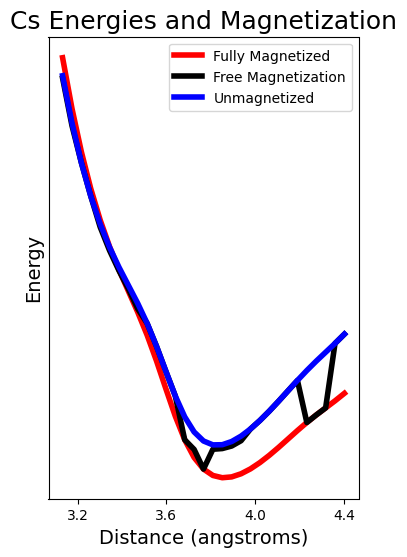

PyObject Text(0.5, 29.0, 'Distance (angstroms)')

In [44]:
figure(figsize=(4, 6))
linewidth = 4
plot(dists[50:80], Cs_Energies44_Fixed_Mag[50:80], linewidth=linewidth, color="red", label="Fully Magnetized")
plot(dists[50:80], Cs_Energies44[50:80], linewidth=linewidth, color="black", label="Free Magnetization" )
plot(dists[50:80], Cs_Energies44_No_Mag[50:80], linewidth=linewidth, label = "Unmagnetized", color="blue")

legend()
title("Cs Energies and Magnetization", fontsize=18)
yticks([])
xticks([3.2, 3.6, 4, 4.4])
ylabel("Energy (eV)", fontsize=14)
xlabel("Distance (angstroms)", fontsize=14)

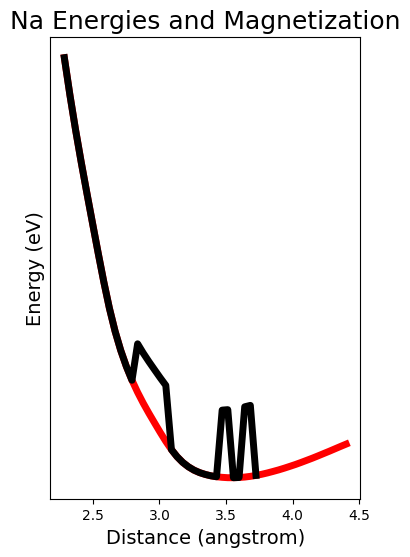

PyObject Text(0.5, 1.0, 'Na Energies and Magnetization')

In [62]:
figure(figsize=(4, 6))
plot(dists[30:80], Na_Energies33_Fixed_Mag[30:80], linewidth=5, color="red", label="Fully Magnetized")
plot(dists[30:64], Na_Energies33[30:64], linewidth=5, color="black", label="Free Magnetization")
yticks([])
xlabel("Distance (angstrom)", fontsize=14)
ylabel("Energy (eV)", fontsize=14)
title("Na Energies and Magnetization", fontsize=18)

In [64]:
argmin(Na_Energies33_Fixed_Mag)

60

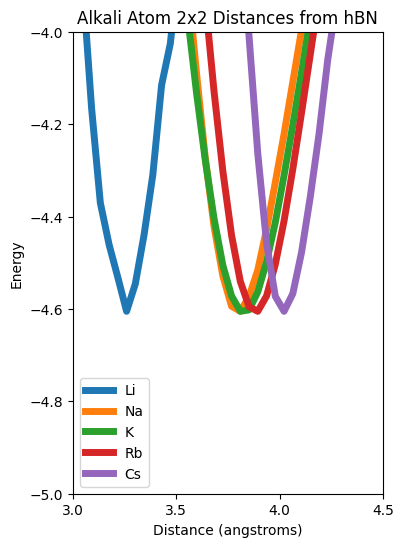

PyObject Text(23.999999999999993, 0.5, 'Energy')

In [70]:
figure(figsize=(4, 6))
title("Comparison of Equilibrium distances 2x2", fontsize=18)
plot(dists, log.(Li_Energies22 .- minimum(Li_Energies22).+ 0.01), linewidth=5, label="Li")

plot(dists, log.(Na_Energies22 .- minimum(Na_Energies22).+ 0.01), linewidth=5, label="Na")
plot(dists, log.(K_Energies22 .- minimum(K_Energies22).+ 0.01), linewidth=5, label="K")

plot(dists, log.(Rb_Energies22 .- minimum(Rb_Energies22).+ 0.01), linewidth=5, label="Rb")
plot(dists, log.(Cs_Energies22 .- minimum(Cs_Energies22).+ 0.01), linewidth=5, label="Cs")
legend()
title("Alkali Atom 2x2 Distances from hBN")
xlim(3, 4.5)
xlabel("Distance (angstroms)")
ylim(-5, -4)
xticks([3, 3.5, 4, 4.5])
ylabel("Energy")

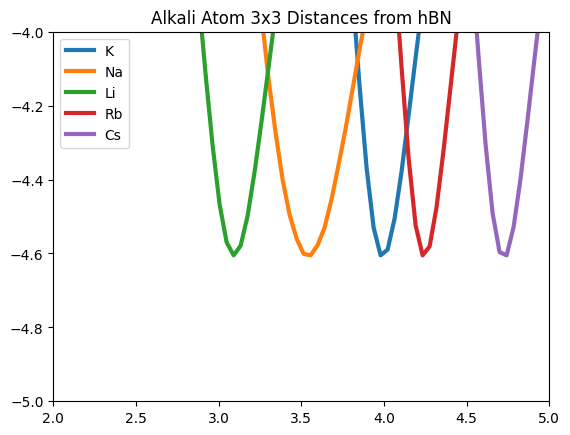

PyObject Text(0.5, 1.0, 'Alkali Atom 3x3 Distances from hBN')

In [31]:
plot(dists, log.(K_Energies33 .- minimum(K_Energies33).+ 0.01), linewidth=3, label="K")
plot(dists[30:80], log.(Na_Energies33_Fixed_Mag[30:80] .- minimum(Na_Energies33_Fixed_Mag).+ 0.01), linewidth=3, label="Na")
plot(dists, log.(Li_Energies33 .- minimum(Li_Energies33).+ 0.01), linewidth=3, label="Li")
plot(dists, log.(Rb_Energies33 .- minimum(Rb_Energies33).+ 0.01), linewidth=3, label="Rb")
plot(dists, log.(Cs_Energies33 .- minimum(Cs_Energies33).+ 0.01), linewidth=3, label="Cs")
legend()
ylim(-5, -4)
xlim(2, 5)
title("Alkali Atom 3x3 Distances from hBN")

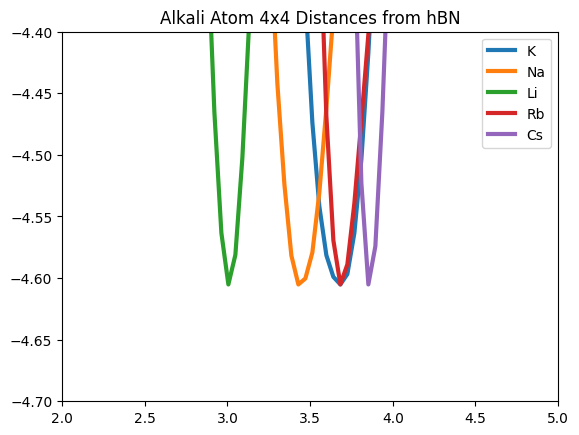

PyObject Text(0.5, 1.0, 'Alkali Atom 4x4 Distances from hBN')

In [37]:
plot(dists[50:70], log.(K_Energies44_Fixed_Mag[50:70] .- minimum(K_Energies44_Fixed_Mag).+ 0.01), linewidth=3, label="K")
plot(dists, log.(Na_Energies44 .- minimum(Na_Energies44).+ 0.01), linewidth=3, label="Na")
plot(dists[20:71], log.(Li_Energies44[20:71].- minimum(Li_Energies44).+ 0.01), linewidth=3, label="Li")
plot(dists, log.(Rb_Energies44 .- minimum(Rb_Energies44).+ 0.01), linewidth=3, label="Rb")
#plot(dists, log.(smooth(Cs_Energies44) .- minimum(Cs_Energies44).+ 0.01) .- 1.3, linewidth=3, label="Cs")
plot(dists[30:80], log.(Cs_Energies44_Fixed_Mag[30:80] .- minimum(Cs_Energies44_Fixed_Mag) .+ 0.01), linewidth=3, label="Cs" )
legend()
ylim(-4.7, -4.4)
xlim(2, 5)
title("Alkali Atom 4x4 Distances from hBN")

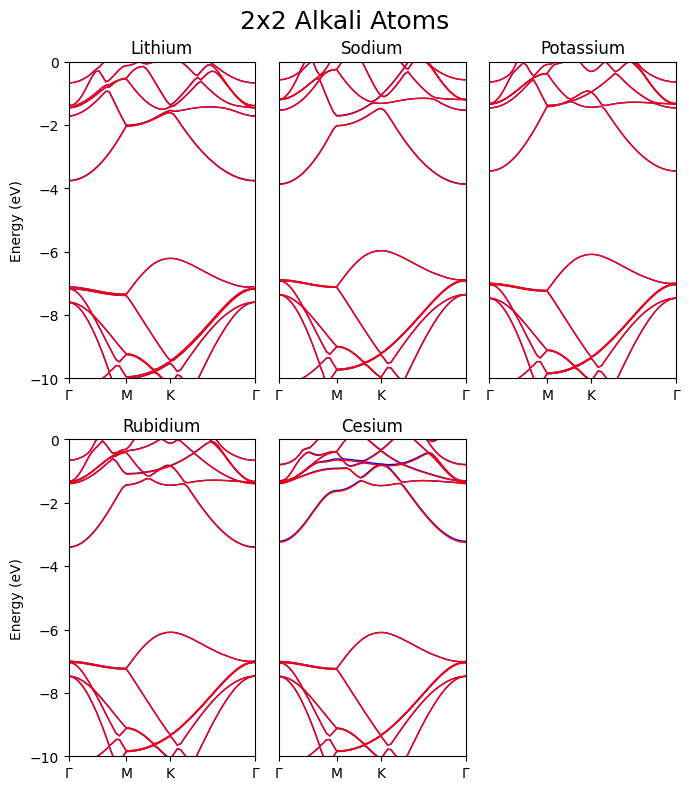

In [114]:
figure(figsize=(7, 12))

linewidth=1

subplot(3, 3, 1)
plot_bands("$li_dir/eigenvals/Lithium22-bands-0.154.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
xlabel("")
title("Lithium")
ylim(-10, 0)
subplot(3, 3, 4)
plot_bands("$rb_dir/eigenvals/Rb22-bands-0.184.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
xlabel("")
title("Rubidium")
ylim(-10, 0)
subplot(3, 3, 2)
plot_bands("$na_dir/eigenvals/Na22-bands-0.18.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
yticks([])
xlabel("")
ylabel("")
title("Sodium")
ylim(-10, 0)
subplot(3, 3, 3)
plot_bands("$k_dir/eigenvals/K22-bands-0.18.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
yticks([])
xlabel("")
ylabel("")
title("Potassium")
ylim(-10, 0)
subplot(3, 3, 5)
plot_bands("$cs_dir/eigenvals/Cs22-bands-0.19.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
yticks([])
xlabel("")
ylabel("")
title("Cesium")
ylim(-10, 0)
suptitle("2x2 Alkali Atoms", fontsize=18)
tight_layout(rect=[0, 0.03, 1, 1])


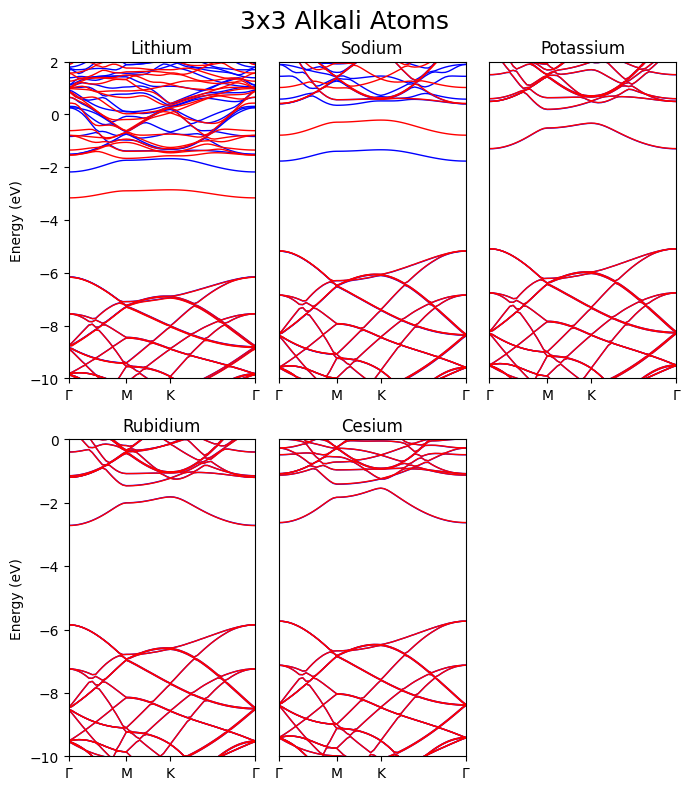

In [113]:
figure(figsize=(7, 12))

linewidth=1
subplot(3, 3, 1)
plot_bands("$li_dir/eigenvals/Lithium33-bands-0.146.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
title("Lithium")
xlabel("")
ylim(-10, 2)
subplot(3, 3, 2)
plot_bands("$na_dir/fixed-magnetization/Na33-bands-0.168.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
title("Sodium")
xlabel("")
yticks([])
ylabel("")
ylim(-10, 0)
subplot(3, 3, 3)
plot_bands("$k_dir/eigenvals/K33-bands-0.188.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
title("Potassium")
xlabel("")
yticks([])
ylabel("")
ylim(-10, 0)
subplot(3, 3, 4)
plot_bands("$rb_dir/eigenvals/Rb33-bands-0.2.eigenvals", linewidth=linewidth,spin=2, to_greek=true)
title("Rubidium")
xlabel("")
ylim(-10, 0)
subplot(3, 3, 5)
plot_bands("$cs_dir/eigenvals/Cs33-bands-0.224.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
title("Cesium")
xlabel("")
yticks([])
ylabel("")
ylim(-10, 0)
suptitle("3x3 Alkali Atoms", fontsize=18)
tight_layout(rect=[0, 0.03, 1, 1])


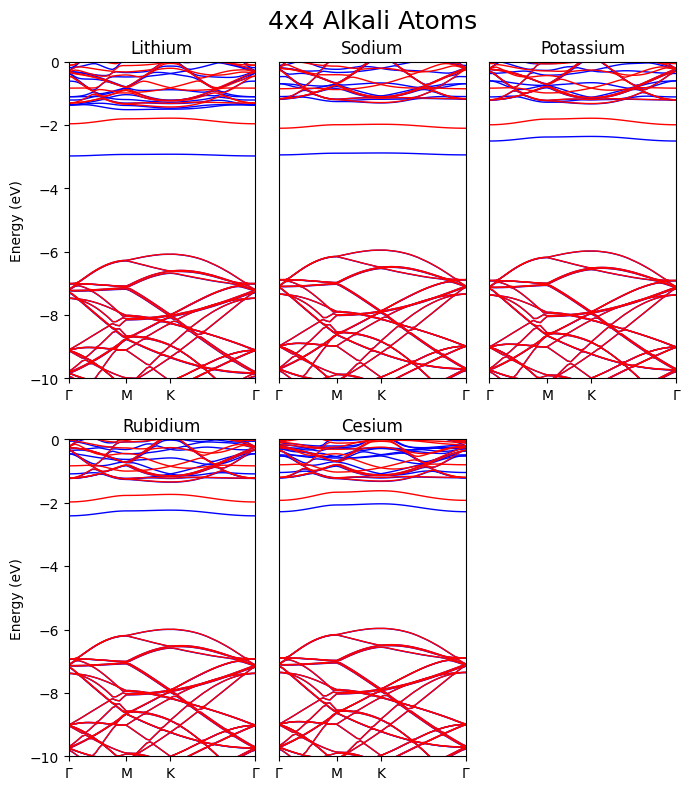

In [109]:
figure(figsize=(7, 12))

linewidth=1
subplot(3, 3, 4)
plot_bands("$rb_dir/eigenvals/Rb44-bands-0.174.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
ylim(-10, 0)
title("Rubidium")
xlabel("")
subplot(3, 3, 1)
plot_bands("$li_dir/eigenvals/Lithium44-bands-0.142.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
ylim(-10, 0)
xlabel("")
title("Lithium")
subplot(3, 3, 2)
plot_bands("$na_dir/eigenvals/Na44-bands-0.162.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
ylim(-10, 0)
xlabel("")
ylabel("")
yticks([])
title("Sodium")
subplot(3, 3, 3)
plot_bands("$k_dir/fixed-magnetization/K44-bands-0.174.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
ylim(-10, 0)
title("Potassium")
ylabel("")
yticks([])
xlabel("")
subplot(3, 3, 5)
#plot_bands("$cs_dir/Cs44-bands-0.178.eigenvals", spin=2, to_greek=true)
plot_bands("$cs_dir/fixed-magnetization/Cs44-bands-0.182.eigenvals", linewidth=linewidth, spin=2, to_greek=true)
ylabel("")
title("Cesium")
ylim(-10, 0)
yticks([])
xlabel("")
suptitle("4x4 Alkali Atoms", fontsize=18, x = 0.54)
tight_layout(rect=[0, 0.03, 1, 1])
